# About this Continuous Assessment
|  |  |
|--|--|
|Assessment| 10|
|Delivery method | Canvas submission of this file after completion |
|Deadline | As specified on Canvas. |
|ILOs|Be able to implement an inverse dynamics controller in task space.|

# Allowed packages 
Do not modify these. Do not add or remove packages.

In [ ]:
# Helper functions and packages
%pip install numpy
%pip install matplotlib


# Allowed imports

<div class="alert alert-block alert-info">
Do not modify, add, or remove imports. Do not add imports anywhere else in this notebook.
</div>

In [ ]:
# Helper functions and packages
import numpy as np
import matplotlib.pyplot as plt


## Instructions
This assessment is made of 2 tasks. There are two points in total for this part of the assessment.   
Each cell is tagged for the assessment, so do not delete or otherwise tamper with the cells. The assignment is to add content to each of the Python cells as requested.

## Verify the spreadsheet

Your student ID will be used to assign you parameters. For each task, look into your row to see what you must implement.

# Dynamics of a 2-DoF Planar Manipulator

Consider the planar manipulator equipped with two revolute joints as depicted. 
- The joint angles are denoted by $q_i$, where $i = 1, 2$, and serve as the generalized coordinates. 
- The mass of link $i$ is represented by $m_i$, while $l_i$ indicates the length of link $i$. 
- The distance from the preceding joint to the center of mass of link $i$ is denoted by $l_{ci}$, and 
- The moment of inertia of link $i$ about an axis perpendicular to the page is $I_i$, passing through the center of mass of link $i$.


  <figure style="margin: 10px; width: 100%; text-align: left;">
    <img src="figures/figure1.png" alt='A single-link robot arm.' style="max-width: 100%; height: 250px;"/>
    <figcaption>Figure 1 - A 2-DoF Planar Manipulator.</figcaption>
  </figure>


The equations of motion of the manipulator can be written as: $D(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = \tau $  

where is the $D(q)$, $C(q,\dot{q})\dot{q}$ represents the Coriolis and centrifugal torque, and $G(q)$ is the gravity torque. 

Please enter the parameters associated with your ID for the dynamics model, as listed in the spreadsheet.

In [ ]:
# Define Parameters for Tasks 1 and 2
############################################################
# TODO:   
# Enter the parameters below (Find them in the spreadsheet)

model_parameters = {
    'm1': 1.53,   # mass of link 1
    'm2': 1.58,   # mass of link 2
    'l1': 0.42,   # length of link 1
    'l2': 0.38,   # length of link 2
    'lc1': 0.21, # distance from preceding joint to the centre of mass of link 1
    'lc2': 0.19,   # distance from preceding joint to the centre of mass of link 2
    'I1': 0.028, # inertia of link 1, kg m^2
    'I2': 0.03, # inertia of link 2, kg m^2
    'g': 9.8,     # gravity acceleration
}
############################################################


In [ ]:
# Define initial joint angles
################################################################################
# TODO:   
# Enter the initial joint angles below (Find them in the spreadsheet)
# Convert them into radians
q1_0 = np.radians(25)          # initial angle of joint 1
q2_0 = np.radians(20)          # initial angle of joint 2
q1_dot_0 = 0      # initial angular velocity of joint 1
q2_dot_0 = 0      # initial angular velocity of joint 2
################################################################################


---
## ✏️ Task 1 - Desired Trajectory
The robot is required to draw a circular trajectory in task space.

The desired motion is defined as:

$$
x_d(t) = x_c + R \cos(\omega t), \quad
y_d(t) = y_c + R \sin(\omega t)
$$

Complete the function below to compute:

- position $X_d(t)$
- velocity $\dot{X}_d(t)$
- acceleration $\ddot{X}_d(t)$

In [ ]:
# Code for Task 1
# Trajectory parameters
xc = 0.3
yc = 0.2
R = 0.1
omega = 1.0

dt = 0.001        # time step (seconds)
T = 10.0          # total simulation time (seconds)

N = int(T / dt)   # number of time steps

time = np.linspace(0.0, T, N)
Xd_hist = np.zeros((N, 2))
Xd_dot_hist = np.zeros((N, 2))
Xd_ddot_hist = np.zeros((N, 2))


for i, t in enumerate(time):
################################################################################
    # TODO: Desired trajectory
    xd = xc + R * np.cos(omega * t)
    yd = yc + R * np.sin(omega * t)

    xd_dot = -R * omega * np.sin(omega * t)
    yd_dot =  R * omega * np.cos(omega * t)

    xd_ddot = -R * omega**2 * np.cos(omega * t)
    yd_ddot = -R * omega**2 * np.sin(omega * t)
################################################################################    
    
    Xd = np.array([xd, yd])
    Xd_dot = np.array([xd_dot, yd_dot])
    Xd_ddot = np.array([xd_ddot, yd_ddot])
    
    # ============================================
    # Store history
    # ============================================
    Xd_hist[i, :] = Xd
    Xd_dot_hist[i, :] = Xd_dot
    Xd_ddot_hist[i, :] = Xd_ddot    

# End of code for Task 1


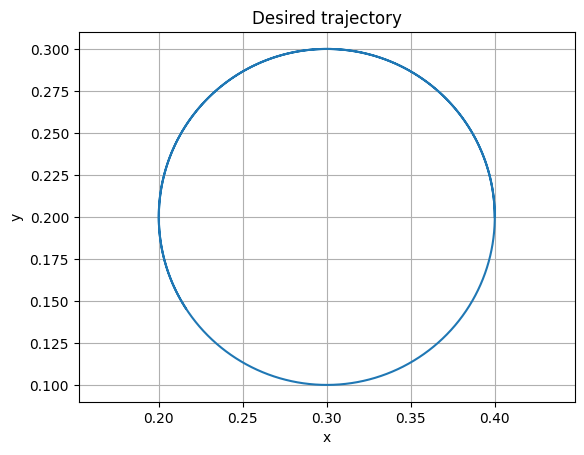

In [ ]:
# Plot

plt.plot(Xd_hist[:, 0], Xd_hist[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Desired trajectory')
plt.axis('equal')
plt.grid()

---
## ✏️ Task 2 -  Task-Space Inverse Dynamics Controller


You are given:

- the robot dynamics:
$$
D(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = u
$$

- and the Jacobian $J(q)$

Implement the task-space inverse dynamics controller to track the desired trajectory:

$$
u = D(q)J^{-1}(q)\left(
\ddot{X}_d - \dot{J}(q,\dot{q})\dot{q}
+ K_D \dot{\tilde{X}} + K_P \tilde{X}
\right) + C + G
$$


#### Objective
Design and implement the controller such that the end-effector accurately follows the desired trajectory in task space.


#### Performance Evaluation

The tracking errors in task space are defined as:

$$
e_x(t) = x_d(t) - x(t), \qquad
e_y(t) = y_d(t) - y(t).
$$

To evaluate overall performance, compute the accumulated tracking errors:

$$
E_x = \sum_{i=0}^{N-1} |e_x[i]| \cdot \Delta t, \qquad
E_y = \sum_{i=0}^{N-1} |e_y[i]| \cdot \Delta t.
$$


#### Controller Tuning Task

Tune the feedback gains:

$$
K_P = \mathrm{diag}(k_{p1}, k_{p2}), \qquad
K_D = \mathrm{diag}(k_{d1}, k_{d2})
$$

such that the following performance requirement is satisfied:

$$
E_x < 0.1, \qquad E_y < 0.1.
$$


In [ ]:
## Kinematics Functions (DON'T MODIFY ANY CODE IN THIS CELL) 
## Use these functions as needed. 

# Forward kinematics. 
def forward_kinematics(q, params):
    """
    Forward kinematics of a planar 2R manipulator.

    Args:
        q: array-like, [q1, q2]
        params: dict with keys 'l1', 'l2'

    Returns:
        np.array([x, y])
    """
    q1, q2 = q
    l1 = params['l1']
    l2 = params['l2']

    x = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    y = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)

    return np.array([x, y])

# Jacobian
def jacobian(q, params):
    """
    Jacobian of a planar 2R manipulator.

    Args:
        q: array-like, [q1, q2]
        params: dict with keys 'l1', 'l2'

    Returns:
        2x2 Jacobian matrix J such that X_dot = J @ q_dot
    """
    q1, q2 = q
    l1 = params['l1']
    l2 = params['l2']

    J11 = -l1 * np.sin(q1) - l2 * np.sin(q1 + q2)
    J12 = -l2 * np.sin(q1 + q2)
    J21 =  l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    J22 =  l2 * np.cos(q1 + q2)

    J = np.array([
        [J11, J12],
        [J21, J22]
    ])

    return J

# Jacobian derivative 
def jacobian_dot(q, qdot, params):
    """
    Time derivative of the Jacobian for a planar 2R manipulator.

    Args:
        q: array-like, [q1, q2]
        qdot: array-like, [q1_dot, q2_dot]
        params: dict with keys 'l1', 'l2'

    Returns:
        2x2 matrix Jdot
    """
    q1, q2 = q
    q1_dot, q2_dot = qdot
    l1 = params['l1']
    l2 = params['l2']

    q12 = q1 + q2
    q12_dot = q1_dot + q2_dot

    Jdot11 = -l1 * np.cos(q1) * q1_dot - l2 * np.cos(q12) * q12_dot
    Jdot12 = -l2 * np.cos(q12) * q12_dot
    Jdot21 = -l1 * np.sin(q1) * q1_dot - l2 * np.sin(q12) * q12_dot
    Jdot22 = -l2 * np.sin(q12) * q12_dot

    Jdot = np.array([
        [Jdot11, Jdot12],
        [Jdot21, Jdot22]
    ])

    return Jdot

# Damped pseudoinverse for numerical robustness
def damped_pseudoinverse(J, damping=1e-4):
    JT = J.T
    return JT @ np.linalg.inv(J @ JT + damping**2 * np.eye(J.shape[0]))

In [ ]:
## Dynamics Functions (DON'T MODIFY ANY CODE IN THIS CELL) 
## Use these functions as needed. 
# Inertial matrix
def Inertial_Matrix(q1, q2, params): 
    '''
    Inputs:
        q1, q2 are scalars, representing the joint angle in radian
        params is a dictionary with dynamic model parameters
    Output:
        D is a 2x2 2D array, representing the inertial matrix
    '''
    # Input necessary parameters as needed
    m1 = params.get('m1')
    m2 = params.get('m2')
    I1 = params.get('I1')
    I2 = params.get('I2')
    l1 = params.get('l1')
    lc1 = params.get('lc1')
    lc2 = params.get('lc2')
    
    c2 = np.cos(q2)
    d22 = I2 + m2 * lc2**2    
    d11 = d22 + I1 + m1 * lc1**2 + m2 * (l1**2 + 2 * l1 * lc2 * c2)
    d12 = d22 + m2 * l1 * lc2 * c2 
    d21 = d12  
    D = np.array([[d11, d12], [d21, d22]])
    return D

# Coriolis torque
def coriolis(q1,q2, q1_dot, q2_dot, params):
    '''
    Inputs:
        q1, q2 are scalars, representing the joint angles in radian
        q1_dot, q2_dot are scalars, representing the joint angular velocities in radian
        params is a dictionary including all system parameters
    Output:
        C is a 1D array with 2 elements
    '''
    # Input necessary parameters as needed
    m2 = params.get('m2')
    l1 = params.get('l1')
    lc2 = params.get('lc2')  
    
    C = np.zeros(2)  # Creates a 1D array with 2 elements, initialized to 0
  
    s2 = np.sin(q2)  
    h = -m2 * l1 * lc2 * s2
    p1 = h  
    p2 = -h  
    C = np.zeros(2)  # Creates a 1D array with 2 elements, initialized to 0
    C[0] = p1 * (q2_dot**2 + 2 * q1_dot * q2_dot)
    C[1] = p2 * q1_dot**2
    return C

# Gravity torque
def gravity(q1,q2,params):
    '''
    Inputs:
        q1, q2 are scalars, representing the joint angle in radian
        params is a dictionary including all system parameters
    Output:
        G is a 1D array with 2 elements
    '''
    # Input necessary parameters as needed
    m1 = params.get('m1')
    m2 = params.get('m2')  
    l1 = params.get('l1')
    lc1 = params.get('lc1')
    lc2 = params.get('lc2')
    g = params.get('g')
         
    G = np.zeros(2)  # Creates a 1D array with 2 elements, initialized to 0

    c1 = np.cos(q1) 
    c12 = np.cos(q1+q2)
    G[0] = (m1*lc1+ m2*l1)*g*c1 + m2*lc2*g*c12
    G[1] = m2*lc2*g*c12   
    return G

def JointAccel(Torque, D, Cqdot, G):
    return np.linalg.inv(D) @ (Torque - Cqdot-G)

# Numerical integration
def UpdateAngle(q, qdot, dt):
    return np.array([q[0] + dt * qdot[0], 
                     q[1] + dt * qdot[1]])

def UpdateVel(qdot, qddot, dt):
    return np.array([qdot[0] + dt * qddot[0], 
                     qdot[1] + dt * qddot[1]])
  

In [ ]:
# Please select appropriate feedback control gains
Kp = np.diag([2500.0, 2500.0])   # Tuning parameters
Kd = np.diag([100.0,  100.0])    # Tuning parameters


In [ ]:
# Code for Task 2
# Inverse Dynamics Controller Design and Simulations

dt = 0.001        # time step (seconds)
T = 10.0          # total simulation time (seconds)

N = int(T / dt)   # number of time steps

time = np.linspace(0.0, T, N)

# Initial joint angles
q_start = np.array([q1_0, q2_0])  

# Initialize q with zeros and set the first row to q_start
q = np.zeros((N, 2))
q[0, :] = q_start

# Initialize qdot with zeros and set the first row to [0, 0]
qdot = np.zeros((N, 2))

# Initialize acceleration array for dynamics calculation
qddot = np.zeros((N, 2))

# Store actual end-effector position history
X_hist = np.zeros((N, 2))

# Store initial end-effector position
X_hist[0, :] = forward_kinematics(q[0, :], model_parameters)

for i in range(N - 1):
    t = time[i]
    #######################################################################
    # TODO: compute errors    
    # Current task-space state
    X     = forward_kinematics(q[i, :], model_parameters)
    J     = jacobian(q[i, :], model_parameters)
    Jdot  = jacobian_dot(q[i, :], qdot[i, :], model_parameters)
    X_dot = J @ qdot[i, :]
        
    e     = Xd_hist[i, :]     - X
    e_dot = Xd_dot_hist[i, :] - X_dot
    
    # TODO: compute desired task acceleration
    v = Xd_ddot_hist[i, :] + Kp @ e + Kd @ e_dot

    # Use inverse when safe, otherwise damped pseudoinverse
    detJ = np.linalg.det(J)
    if abs(detJ) < 1e-6:
        J_inv = damped_pseudoinverse(J, damping=1e-3)
    else:
        J_inv = np.linalg.inv(J)
   
    # TODO: compute joint acceleration using J^{-1}
    aq = J_inv @ (v - Jdot @ qdot[i, :])
    
    # TODO: compute control input
    D = Inertial_Matrix(q[i,0], q[i,1], model_parameters)
    C = coriolis(q[i,0], q[i,1], qdot[i,0], qdot[i,1], model_parameters)
    G = gravity(q[i,0], q[i,1], model_parameters)    
    u = D @ aq + C + G
    
    qddot[i+1, :] = JointAccel(u, D, C, G)

    # Movement integration
    qdot[i + 1, :] = UpdateVel(qdot[i, :], qddot[i+1, :], dt)
    q[i + 1, :] = UpdateAngle(q[i, :], qdot[i + 1, :], dt) 
    # Record current end-effector position
    X_hist[i, :] = X  

# Store final end-effector position
X_hist[N - 1, :] = forward_kinematics(q[N - 1, :], model_parameters)

e_x = Xd_hist[:, 0] - X_hist[:, 0]
e_y = Xd_hist[:, 1] - X_hist[:, 1]

E_x = np.sum(np.abs(e_x)) * dt
E_y = np.sum(np.abs(e_y)) * dt

print("Accumulated error in x:", E_x)
print("Accumulated error in y:", E_y)


Accumulated error in x: 0.01010118644131624
Accumulated error in y: 0.009886048749216282


In [ ]:
# Marking variables (don't modify)
ansT2_X = X_hist
ansT2_E_x = E_x
ansT2_E_y = E_y
# End of code for Task 2

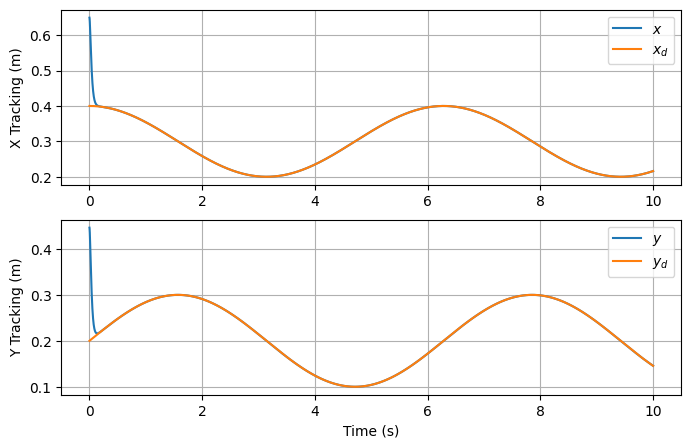

In [ ]:
plt.figure(figsize=(8, 5))
plt.subplot(2,1,1)
plt.plot(time, X_hist[:, 0], label=r'$x$ ')
plt.plot(time, Xd_hist[:, 0], label=r'$x_d$')
plt.ylabel('X Tracking (m)')
plt.grid(True)
plt.legend()

plt.subplot(2,1,2)
plt.plot(time, X_hist[:, 1], label=r'$y$ ')
plt.plot(time, Xd_hist[:, 1], label=r'$y_d$')
plt.xlabel('Time (s)')
plt.ylabel('Y Tracking (m)')

plt.grid(True)
plt.legend()

plt.show()

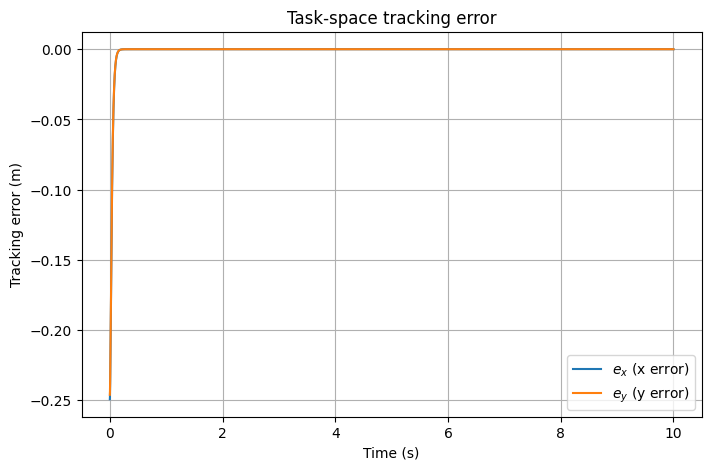

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(time, e_x, label=r'$e_x$ (x error)')
plt.plot(time, e_y, label=r'$e_y$ (y error)')

plt.xlabel('Time (s)')
plt.ylabel('Tracking error (m)')
plt.title('Task-space tracking error')
plt.grid(True)
plt.legend()

plt.show()
